# EDA — Proyek Prediksi USD/IDR

Analisis eksploratif terhadap `aligned_dataset.csv` (nilai tukar USD/IDR harian +
gabungan berita harian) sebelum membangun ekstraksi fitur NLP dan model baseline.

**Tujuan notebook ini:**
1. Memahami cakupan tanggal, data yang hilang, dan kualitas data
2. Mengkarakterisasi pergerakan `usd_idr` (tren, perubahan harian, keseimbangan naik/turun)
3. Mengkarakterisasi volume berita (`jumlah_berita`) dan panjang teks
4. Mencatat hal-hal yang perlu diputuskan sebelum tahap pemodelan


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

pd.set_option('display.max_colwidth', 80)
plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


## 1. Memuat data & struktur dasar

In [2]:
df = pd.read_csv('/mnt/user-data/uploads/aligned_dataset_1.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)
print(f"Jumlah baris: {df.shape[0]}, jumlah kolom: {df.shape[1]}")
print(f"Rentang tanggal: {df['date'].min().date()}  s.d.  {df['date'].max().date()}")
df.head()


Jumlah baris: 1202, jumlah kolom: 5
Rentang tanggal: 2021-09-01  s.d.  2026-09-01


,date,usd_idr,jumlah_berita,judul_gabungan,konten_gabungan
0,2021-09-01,14284,5,"I’ve paid off almost $200,000 of student loans in 3 years: Here's my best ad...","In 2015, I graduated law school with six figures of student loan debt. Since..."
1,2021-09-02,14281,5,Supreme Court refuses to block Texas law that bans most abortions | If you c...,The Supreme Court declined to block a Texas law banning most abortions in a ...
2,2021-09-03,14261,4,"Jobs report disappoints — only 235,000 positions added vs. expectations of 7...","Job creation for August was a huge disappointment, with the economy adding j..."
3,2021-09-06,14239,7,"'Stagflation' is the greatest threat to Europe’s recovery, warns ex-Italian ...",Former Italian Prime Minister Mario Monti told CNBC Saturday that he believe...
4,2021-09-07,14195,6,"Malaysia will start treating Covid as 'endemic' around end-October, trade mi...",Malaysia will start treating Covid-19 as an endemic disease around the end o...


In [3]:
print("Nilai yang hilang per kolom:")
print(df.isna().sum())


Nilai yang hilang per kolom:
date                0
usd_idr             0
jumlah_berita       0
judul_gabungan     17
konten_gabungan    17
dtype: int64


**Catatan:** `judul_gabungan` dan `konten_gabungan` kosong pada hari dengan
`jumlah_berita == 0`. Perlu diputuskan nanti: baris ini tetap dipakai untuk baseline
harga saja, atau dikecualikan dari pelatihan fitur NLP.

In [4]:
baris_tanpa_berita = df[df['judul_gabungan'].isna()]
print(f"Baris tanpa teks berita: {len(baris_tanpa_berita)}")
print(f"Nilai jumlah_berita pada baris tersebut: {baris_tanpa_berita['jumlah_berita'].unique()}")


Baris tanpa teks berita: 17
Nilai jumlah_berita pada baris tersebut: [0]


## 2. Cakupan tanggal & data yang hilang

In [5]:
rentang_penuh = pd.date_range(df['date'].min(), df['date'].max(), freq='D')
tanggal_ada = set(df['date'])
tanggal_hilang = [d for d in rentang_penuh if d not in tanggal_ada]
df_hilang = pd.DataFrame({'date': tanggal_hilang})
df_hilang['hari'] = df_hilang['date'].dt.day_name()

print(f"Total hari kalender dalam rentang: {len(rentang_penuh)}")
print(f"Baris yang tersedia:                {len(df)}")
print(f"Hari yang hilang:                   {len(df_hilang)}")
print()
print("Hari yang hilang berdasarkan nama hari:")
print(df_hilang['hari'].value_counts())


Total hari kalender dalam rentang: 1827
Baris yang tersedia:                1202
Hari yang hilang:                   625

Hari yang hilang berdasarkan nama hari:
hari
Saturday     261
Sunday       261
Friday        25
Monday        23
Thursday      23
Wednesday     18
Tuesday       14
Name: count, dtype: int64


Jika hari yang hilang didominasi Sabtu/Minggu, itu wajar (pasar valas tidak
diperdagangkan di akhir pekan). Hari kerja yang hilang kemungkinan besar adalah hari
libur nasional — layak dicek sekilas, tapi bukan prioritas utama.

## 3. Pergerakan harga USD/IDR

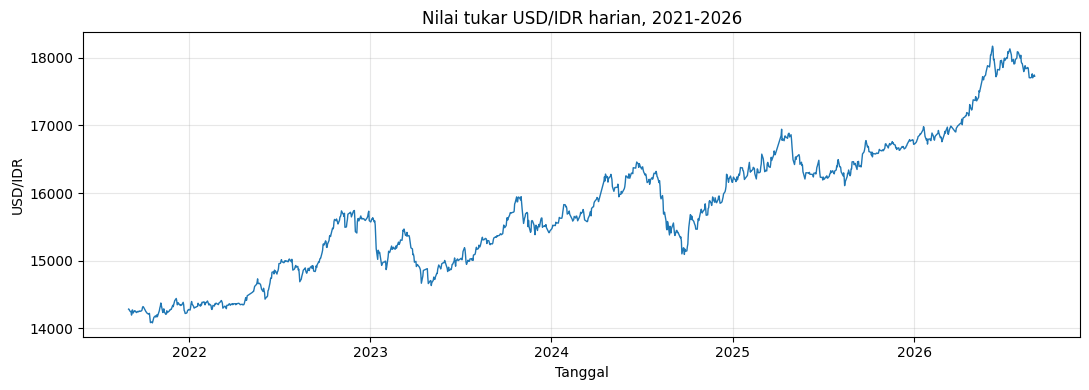

In [6]:
fig, ax = plt.subplots()
ax.plot(df['date'], df['usd_idr'], linewidth=1)
ax.set_title('Nilai tukar USD/IDR harian, 2021-2026')
ax.set_xlabel('Tanggal')
ax.set_ylabel('USD/IDR')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()


In [7]:
df['perubahan_persen'] = df['usd_idr'].pct_change() * 100
df['arah'] = np.where(df['perubahan_persen'] > 0, 1,
               np.where(df['perubahan_persen'] < 0, 0, np.nan))

print("Ringkasan perubahan harian (%):")
print(df['perubahan_persen'].describe())


Ringkasan perubahan harian (%):
count    1201.000000
mean        0.018538
std         0.333416
min        -1.401306
25%        -0.147770
50%         0.038521
75%         0.209884
max         1.908902
Name: perubahan_persen, dtype: float64


**Catatan formulasi target:** `arah` di sini adalah perubahan pada hari yang sama
(t vs t-1), hanya untuk melihat distribusi. Untuk pemodelan sesungguhnya, target harus
`arah_{t+1}` — dibangun dengan pergeseran maju satu hari, sehingga fitur berita hari-t
memprediksi pergerakan hari t+1 (bukan hari yang sama, agar tidak terjadi kebocoran
data/data leakage).

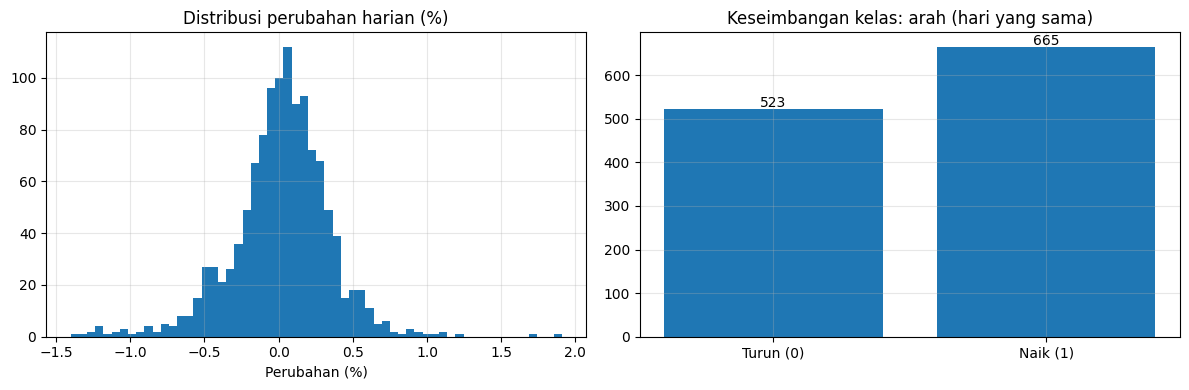

Naik: 665 (56.0%)
Turun: 523 (44.0%)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['perubahan_persen'].dropna(), bins=60)
axes[0].set_title('Distribusi perubahan harian (%)')
axes[0].set_xlabel('Perubahan (%)')

jumlah_arah = df['arah'].value_counts(dropna=True).sort_index()
axes[1].bar(['Turun (0)', 'Naik (1)'], jumlah_arah.values)
axes[1].set_title('Keseimbangan kelas: arah (hari yang sama)')
for i, v in enumerate(jumlah_arah.values):
    axes[1].text(i, v + 5, str(int(v)), ha='center')

plt.tight_layout()
plt.show()

total = jumlah_arah.sum()
print(f"Naik: {jumlah_arah.get(1, 0)} ({jumlah_arah.get(1, 0)/total*100:.1f}%)")
print(f"Turun: {jumlah_arah.get(0, 0)} ({jumlah_arah.get(0, 0)/total*100:.1f}%)")


**Mengapa ini penting:** jika keseimbangan naik/turun tidak 50/50, baseline naif
("selalu prediksi kelas mayoritas") sudah punya akurasi lebih tinggi dari 50% — model
gabungan harus mengalahkan angka itu, bukan hanya mengalahkan 50%.

## 4. Volume berita (`jumlah_berita`)

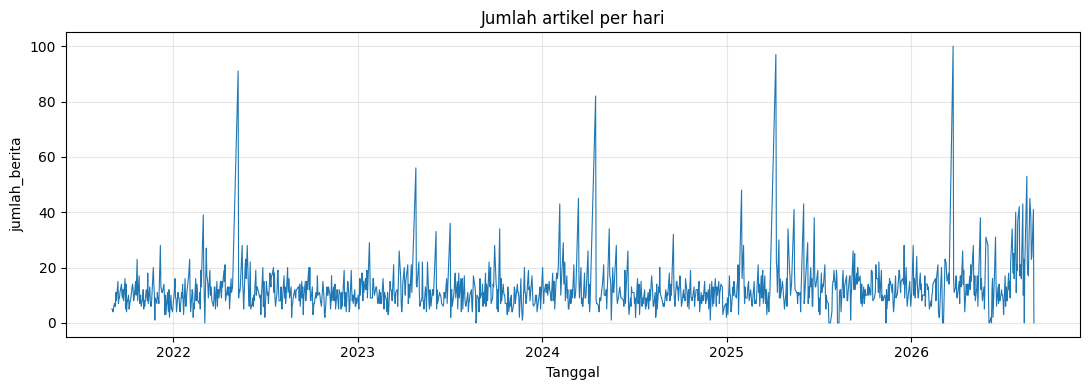

count    1202.000000
mean       11.989185
std         8.148950
min         0.000000
25%         8.000000
50%        11.000000
75%        14.000000
max       100.000000
Name: jumlah_berita, dtype: float64


In [9]:
fig, ax = plt.subplots()
ax.plot(df['date'], df['jumlah_berita'], linewidth=0.8)
ax.set_title('Jumlah artikel per hari')
ax.set_xlabel('Tanggal')
ax.set_ylabel('jumlah_berita')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

print(df['jumlah_berita'].describe())


**Cek volume vs volatilitas.** Apakah hari dengan berita lebih banyak cenderung
punya pergerakan harga lebih besar? Ini sinyal awal yang murah untuk melihat apakah
`jumlah_berita` sendiri cukup informatif.

Korelasi(jumlah_berita, |perubahan %|): 0.157


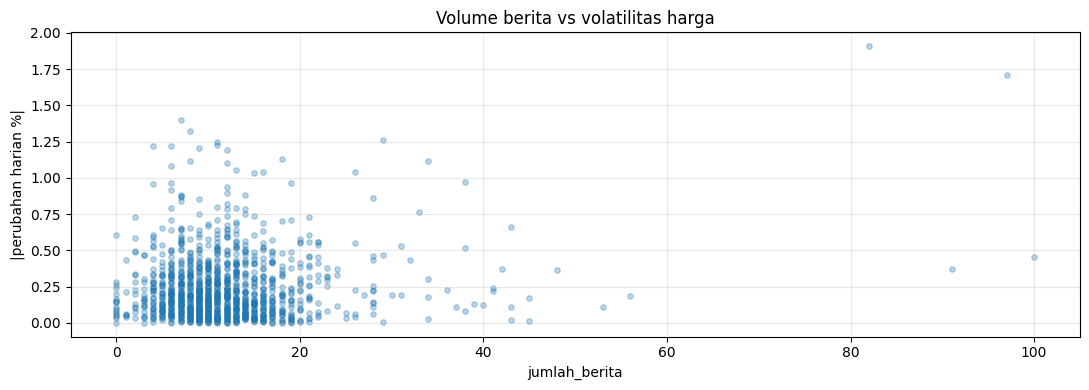

In [10]:
df['abs_perubahan_persen'] = df['perubahan_persen'].abs()
korelasi = df[['jumlah_berita', 'abs_perubahan_persen']].corr().iloc[0, 1]
print(f"Korelasi(jumlah_berita, |perubahan %|): {korelasi:.3f}")

fig, ax = plt.subplots()
ax.scatter(df['jumlah_berita'], df['abs_perubahan_persen'], alpha=0.3, s=15)
ax.set_xlabel('jumlah_berita')
ax.set_ylabel('|perubahan harian %|')
ax.set_title('Volume berita vs volatilitas harga')
plt.tight_layout()
plt.show()


## 5. Panjang teks berita

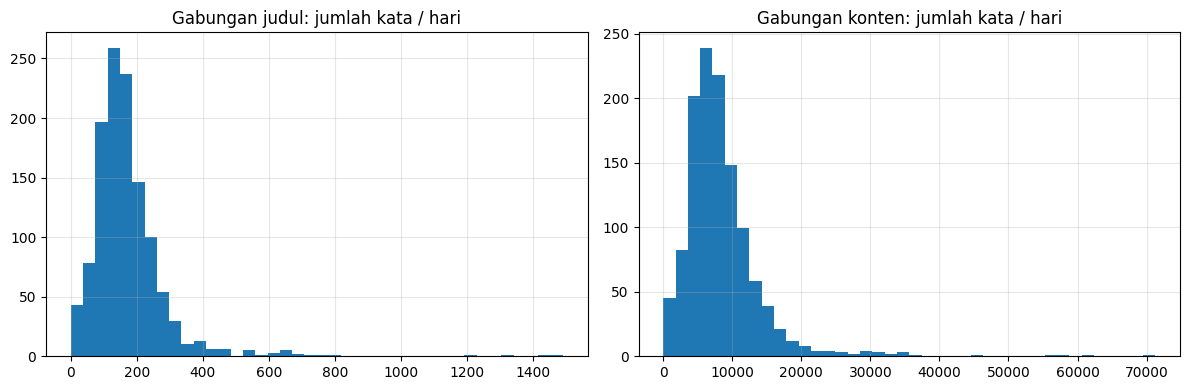

,jumlah_kata_judul,jumlah_kata_konten
count,1202.000000,1202.000000
mean,171.835275,8424.997504
std,120.110418,5864.307710
min,0.000000,0.000000
25%,109.000000,5177.250000
50%,151.000000,7424.000000
75%,204.000000,10198.750000
max,1490.000000,71278.000000


In [11]:
df['jumlah_kata_judul'] = df['judul_gabungan'].fillna('').apply(lambda x: len(x.split()))
df['jumlah_kata_konten'] = df['konten_gabungan'].fillna('').apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['jumlah_kata_judul'], bins=40)
axes[0].set_title('Gabungan judul: jumlah kata / hari')
axes[1].hist(df['jumlah_kata_konten'], bins=40)
axes[1].set_title('Gabungan konten: jumlah kata / hari')
plt.tight_layout()
plt.show()

df[['jumlah_kata_judul', 'jumlah_kata_konten']].describe()


**Catatan:** karena `konten_gabungan` menggabungkan semua artikel dalam satu hari,
jumlah katanya ikut membesar seiring `jumlah_berita` — perlu dipertimbangkan saat
ekstraksi fitur (misalnya pembatasan panjang teks/truncation) agar hari dengan banyak
artikel tidak mendominasi begitu saja.

## 6. Ringkasan temuan & keputusan yang diperlukan

**Kualitas data**
- 1.202 baris harian, 2021-09-01 s.d. 2026-09-01 (~5 tahun). Hari yang hilang mayoritas
  akhir pekan; sisanya kemungkinan hari libur — tidak perlu perlakuan khusus.
- 17 baris tanpa teks berita: tetap dipakai untuk baseline harga saja; untuk model
  gabungan, putuskan apakah dikecualikan atau diberi flag `has_news`.

**Formulasi target**
- Keseimbangan kelas naik/turun (hari yang sama): perlu dicek dari output di atas —
  jika condong ke satu sisi, baseline naif sudah punya akurasi > 50%, jadi model
  gabungan harus mengalahkan baseline itu, bukan 50%.
- Perubahan harian dalam persentase kecil → klasifikasi biner (naik/turun) lebih masuk
  akal dibanding regresi nilai eksak.

**Volume & panjang teks**
- Perhatikan korelasi `jumlah_berita` vs `|perubahan %|` di atas — sinyal awal yang
  lemah, kandidat fitur sekunder, bukan fitur utama.
- `konten_gabungan` yang sangat panjang pada hari-hari ramai berita perlu dibatasi
  panjangnya saat ekstraksi fitur.

**Langkah selanjutnya**
1. Menentukan kebijakan untuk hari/baris yang hilang sebelum membangun
   `src/feature_extraction.py`
2. Lanjut ke ekstraksi fitur (VADER + TF-IDF) dan pembagian data
   train/val/test secara kronologis
